In [1]:
import os
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import cartopy.util as cutil
import cmocean
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

import xcdat as xc
from global_land_mask import globe

/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.27.0
  warnings.warn(
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/zespinosa/conda-envs/cenv/share/proj failed


In [2]:
def get_grid_cell_area(
    ds: xr.Dataset,
) -> xr.Dataset:
    # Use xcdat to add lat/lon bounds
    ds = ds.bounds.add_bounds("X")
    ds = ds.bounds.add_bounds("Y")
    # Use bounds to calculate grid cell area
    lat_bnds = ds.lat_bnds
    lon_bnds = ds.lon_bnds

    if lat_bnds.ndim == 3:
        lat_bnds = lat_bnds.isel(time=0)
        lon_bnds = lon_bnds.isel(time=0)

    # Radius of earth in km
    R = 6371 # Radius of earth in km

    # A = pi*R^2*(sin(lat2)-sin(lat1))*(lon2-lon1)/180 where longitudes are in degrees and latitudes are in radians
    areacello = np.pi*(R**2)*(np.sin(np.deg2rad(lat_bnds[:, 1])) - np.sin(np.deg2rad(lat_bnds[:, 0]))) * (lon_bnds[:, 1] - lon_bnds[:, 0])/180

    return areacello


In [3]:
cesm2_ice_anoms = xr.open_dataset("../data/cesm2_ice_monthly_1950-01_2023-12-anoms.nc")
cesm2_ice = xr.open_dataset("../data/cesm2_ice_monthly_1950-01_2023-12-regrid.nc")
cesm2_ice_clim = xr.open_dataset("../data/cesm2_ice_monthly_1950-01_2023-12-clim.nc")

# SIA and SIE anoms and raw values
si_cesm2 = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_CESM_SH_si-anoms.nc")
si_cesm2_raw = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_CESM_SH_si.nc")

/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/coding/times.py:682: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [4]:
### Load JJA 2023 ###
time_slice = slice("2023-01-15", "2023-08-15")

# dA/dt Anoms
da_thermo = cesm2_ice_anoms["daidtt"].sel(time=time_slice) 
da_dynamic = cesm2_ice_anoms["daidtd"].sel(time=time_slice) 
# dA/dt
da_thermo_raw = cesm2_ice["daidtt"].sel(time=time_slice) 
da_dynamic_raw = cesm2_ice["daidtd"].sel(time=time_slice) 

def calc_avg(ds):
    """
    Calculate spatially weighted average using xcdat of SIA tendencies
    1. Select SH
    2. Get areacello in km^2
    3. Get number of days in each month
    4. Convert tendencies %/day -> fraction/month
    5. Multiply by area, sum over all SH and divide by 1e6 to get 1e6 km^2
    """
    ds = ds.sel(lat=slice(-90, 0)).rename("var").to_dataset()

    areacello = get_grid_cell_area(ds=ds)

    # Number of days in each month 
    ndays = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] 
    ndays = xr.DataArray(ndays[:len(ds.time)], dims=["time"], coords=[ds.time])

    lat, lon = "lat", "lon"
    div = 1e6
    sia = ((ds*ndays*areacello/100).sum([lat, lon]) / div)
    # sia = ((ds*areacello).sum([lat, lon]) / div)

    return sia["var"]


def get_land_sea_mask(ds):
    """
    Creates a land_sea_mask using global_land_mask and ds
    """
    # Swap lon from 0-360 to -180-180 using xarray
    ds = xc.swap_lon_axis(ds, to=(-180., 180.))
    # Make a grid
    lon_grid, lat_grid = np.meshgrid(ds.lon,ds.lat)
    land_mask = globe.is_land(lat_grid, lon_grid)
    # Create xarray using land_mask
    land_mask = xr.DataArray(land_mask, coords=[ds.lat, ds.lon], dims=["lat", "lon"])
    land_mask = land_mask.rename("land_mask").to_dataset()
    # Add bounds
    land_mask = land_mask.bounds.add_bounds("X")
    land_mask = land_mask.bounds.add_bounds("Y")
    land_mask = xc.swap_lon_axis(land_mask, to=(0, 360))

    return land_mask


def apply_land_mask(ds, land_mask):
    # Only select regions that are not land
    # ds = ds.where(land_mask["land_mask"] == 0, drop=True)

    return ds

lsm = get_land_sea_mask(cesm2_ice_anoms)

da_dynamic = calc_avg(apply_land_mask(da_dynamic, lsm))
da_thermo = calc_avg(apply_land_mask(da_thermo, lsm))
da_dynamic_raw = calc_avg(apply_land_mask(da_dynamic_raw, lsm))
da_thermo_raw = calc_avg(apply_land_mask(da_thermo_raw, lsm))

In [5]:
# Sanity check SIA calculations (before we run this, uncomment 2nd line in calc_avg for sia)
sia = calc_avg(cesm2_ice_anoms["aice"].sel(time=time_slice))
sia

<xarray.DataArray 'var' (time: 8)>
array([-0.23074167, -0.05680921, -0.08638797, -0.33097431, -0.58180164,
       -0.66194979, -0.79585651, -0.79642165])
Coordinates:
  * time     (time) datetime64[ns] 2023-01-15 2023-02-15 ... 2023-08-15

In [6]:
def plot_tendency_timeseries(time, dynamic, thermo, sum, label_info, raw: bool = False):
    # colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00']
    linewidth = 3
    dyn_mean = np.around(np.sum(dynamic), 2) 
    ther_mean = np.around(np.sum(thermo), 2)

    # Daily Integration
    ndays = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] 
    dynamic_sum = np.sum(dynamic.resample(time='D').interpolate())/np.mean(ndays[:len(time)])
    thermo_sum = np.sum(thermo.resample(time='D').interpolate())/np.mean(ndays[:len(time)])

    # Monthly Coarse Integration
    # thermo = np.sum(thermo)
    # dynamic = np.sum(dynamic)

    if raw:
        si_beg = si_cesm2_raw.sel(time="2023-01")["sia"].values[0]
        si_end = si_cesm2_raw.sel(time="2023-08")["sia"].values[0]
    else:
        si_beg = si_cesm2.sel(time="2023-01")["sia"].values[0]
        si_end = si_cesm2.sel(time="2023-08")["sia"].values[0]

    print("01-SIA (10^6 km^2):", si_beg)
    print("08-SIA (10^6 km^2):", si_end)
    sum_mean = np.around(thermo_sum + dynamic_sum + si_beg, 2)
    print("SIAT integrated + End (10^6 km^2):", sum_mean.values)

    # Change fig size
    fig = plt.figure(figsize=(10, 5))

    plt.hlines(0, xmin=time[0], xmax=time[-1], color="black", linestyle="dashed", linewidth=linewidth)
    # plt.plot(time, dynamic, label=f"Dynamic ({dyn_mean})", linewidth=linewidth)
    # plt.plot(time, thermo, label=f"Thermo ({ther_mean})", linewidth=linewidth)
    # plt.plot(time, dynamic + thermo, label=f"Sum ({sum_mean})", linewidth=linewidth)
    plt.plot(time, dynamic, label=f"Dynamic", linewidth=linewidth)
    plt.plot(time, thermo, label=f"Thermodynamic ", linewidth=linewidth)
    plt.plot(time, dynamic + thermo, label=f"Sum", linewidth=linewidth)
    plt.grid()
    plt.legend()
    plt.ylabel(label_info["ylabel"], fontsize=12)
    plt.title(label_info["left_title"], loc="left", fontsize=16, fontweight="bold")
    plt.title(label_info["right_title"], loc="right", fontsize=16, fontweight="bold")

    plt.savefig(label_info["path"] + ".pdf", dpi=400, bbox_inches="tight")
    plt.savefig(label_info["path"] + ".png", dpi=400, bbox_inches="tight")


# Anomalies

01-SIA (10^6 km^2): -0.7443279639241769
08-SIA (10^6 km^2): -2.5691021012157664
SIAT integrated + End (10^6 km^2): -2.38


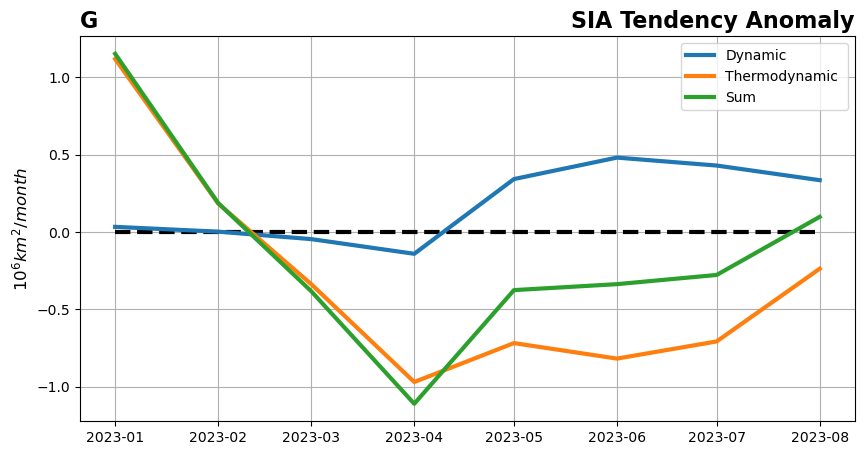

In [7]:
plot_tendency_timeseries(
    time=np.arange("2023-01-01", "2023-09-01", dtype="datetime64[M]"), 
    dynamic=da_dynamic,
    thermo=da_thermo,
    sum=da_dynamic + da_thermo,
    label_info={
        "right_title": "SIA Tendency Anomaly",
        "ylabel": r"$10^6 km^2/month$",
        "left_title": "G",
        "path": "figures/Figure_SX_SIA_tendency_timeseries"
    },
    raw=False
)

# Raw Values

01-SIA (10^6 km^2): 1.1178890318127672
08-SIA (10^6 km^2): 6.844499337228654
SIAT integrated + End (10^6 km^2): 6.71


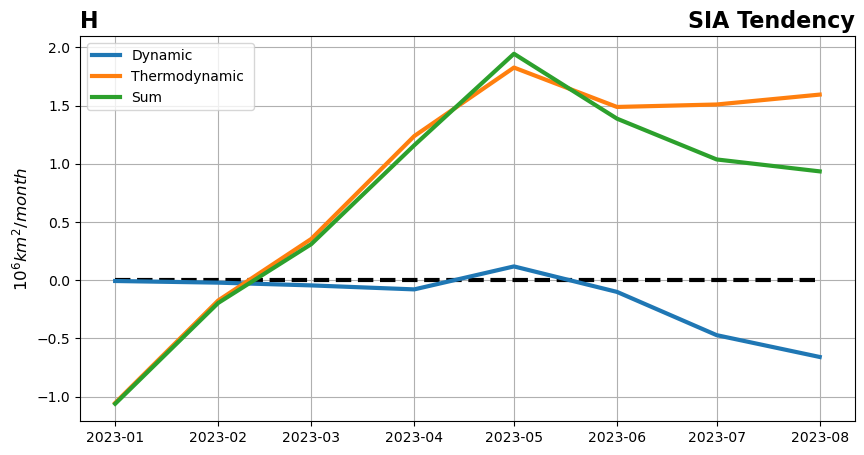

In [8]:
plot_tendency_timeseries(
    time=np.arange("2023-01-01", "2023-09-01", dtype="datetime64[M]"), 
    dynamic=da_dynamic_raw,
    thermo=da_thermo_raw,
    sum=da_dynamic_raw + da_thermo_raw,
    label_info={
        "right_title": "SIA Tendency",
        # "ylabel": "Sea Ice Area Tendency",
        "ylabel": r"$10^6 km^2/month$",
        "left_title": "H",
        "path": "figures/Figure_SX_SIV_tendency_timeseries"
    },
    raw=True
)